# 🛒 Rossmann Store Sales Forecasting
## Notebook 3: Classical Time Series Models

**Models covered:**
1. SARIMA — Seasonal ARIMA (univariate baseline)
2. SARIMAX — SARIMA with exogenous variables
3. Holt-Winters Exponential Smoothing

**Approach:** We model Store 1 as a representative store.
All models are trained on log-transformed sales and evaluated 
on the validation set using RMSE, MAE and MAPE.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX as sm_SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [3]:
train_df = pd.read_csv('../data/processed/train_processed.csv', parse_dates=['Date'])
val_df = pd.read_csv('../data/processed/val_processed.csv', parse_dates=['Date'])

# Extract store 1
store1_train = train_df[train_df['Store'] == 1].set_index('Date').asfreq('D')
store1_val = val_df[val_df['Store'] == 1].set_index('Date').asfreq('D')

print(f"Store 1 Train: {store1_train.index.min()} → {store1_train.index.max()}")
print(f"Store 1 Val  : {store1_val.index.min()} → {store1_val.index.max()}")
print(f"Train size   : {len(store1_train)} days")
print(f"Val size     : {len(store1_val)} days")

Store 1 Train: 2013-02-04 00:00:00 → 2015-06-13 00:00:00
Store 1 Val  : 2015-06-15 00:00:00 → 2015-07-31 00:00:00
Train size   : 860 days
Val size     : 47 days


## 1. Evaluation Metrics

We define evaluation metrics before modelling to ensure consistent 
comparison across all models.

- **RMSE** — Root Mean Squared Error, penalizes large errors heavily
- **MAE** — Mean Absolute Error, robust to outliers
- **MAPE** — Mean Absolute Percentage Error, scale-independent, 
  interpretable as average % error

In [4]:
def evaluate_model(actual, predicted, model_name):
    # Back transform from log scale
    actual_exp = np.expm1(actual)
    predicted_exp = np.expm1(predicted)
    
    rmse = np.sqrt(np.mean((actual_exp - predicted_exp)**2))
    mae = np.mean(np.abs(actual_exp - predicted_exp))
    mape = np.mean(np.abs((actual_exp - predicted_exp) / actual_exp)) * 100
    
    print(f"=== {model_name} ===")
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAE  : {mae:,.2f}")
    print(f"MAPE : {mape:.2f}%")
    print("-" * 30)
    
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

results = []

## 2. SARIMA Model

We use auto_arima to search for optimal (p,d,q)(P,D,Q)[7] parameters
using AIC as the selection criterion. This is more rigorous than 
manually picking parameters from ACF/PACF alone.

Our ACF/PACF analysis suggested SARIMA(1,0,1)(1,1,1)[7] as a starting 
candidate — auto_arima will confirm or refine this.

In [5]:
y_train = store1_train['LogSales'].dropna()

print("Running auto_arima... (this may take 2-3 minutes)")

sarima_auto = pm.auto_arima(
    y_train,
    start_p=1, start_q=1,
    max_p=3, max_q=3,
    m=7,                    # weekly seasonality
    d=0,                    # confirmed stationary
    D=1,                    # seasonal differencing
    seasonal=True,          
    stepwise=True,          # faster search
    information_criterion='aic',
    trace=True,             # print search progress
    error_action='ignore',
    suppress_warnings=True
)

print("\nBest model:", sarima_auto.order, sarima_auto.seasonal_order)
print("AIC:", round(sarima_auto.aic(), 2))
print("BIC:", round(sarima_auto.bic(), 2))

Running auto_arima... (this may take 2-3 minutes)
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[7] intercept   : AIC=inf, Time=0.71 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=346.285, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=-317.288, Time=0.23 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=344.386, Time=0.01 sec
 ARIMA(1,0,0)(0,1,0)[7] intercept   : AIC=-66.295, Time=0.08 sec
 ARIMA(1,0,0)(2,1,0)[7] intercept   : AIC=-395.454, Time=0.99 sec
 ARIMA(1,0,0)(2,1,1)[7] intercept   : AIC=inf, Time=1.48 sec
 ARIMA(1,0,0)(1,1,1)[7] intercept   : AIC=inf, Time=0.66 sec
 ARIMA(0,0,0)(2,1,0)[7] intercept   : AIC=-75.831, Time=0.31 sec
 ARIMA(2,0,0)(2,1,0)[7] intercept   : AIC=-393.506, Time=0.98 sec
 ARIMA(1,0,1)(2,1,0)[7] intercept   : AIC=-393.488, Time=0.69 sec
 ARIMA(0,0,1)(2,1,0)[7] intercept   : AIC=-286.571, Time=0.43 sec
 ARIMA(2,0,1)(2,1,0)[7] intercept   : AIC=-411.920, Time=1.45 sec
 ARIMA(

### Auto_arima Results

Best model selected: **SARIMA(3,0,3)(0,1,2)[7]**

- **p=3, q=3** — more complex non-seasonal component than ACF/PACF 
  suggested, indicating richer short-term autocorrelation structure
- **d=0** — confirms stationarity finding from EDA
- **P=0** — no seasonal AR term needed once seasonal differencing applied
- **D=1** — seasonal differencing removes weekly unit root
- **Q=2** — two seasonal MA terms capture the weekly pattern effectively
- **AIC=-602.61** — selection criterion, lower is better
- **BIC=-557.03** — BIC penalizes complexity more than AIC

Note: Our ACF/PACF manual suggestion of SARIMA(1,0,1)(1,1,1)[7] was a 
reasonable starting point but auto_arima's exhaustive search found a 
superior model. This highlights the importance of formal model selection 
over purely visual identification.

In [10]:
# Fit best SARIMA model
sarima_model = sm_SARIMAX(
    y_train,
    order=(3, 0, 3),
    seasonal_order=(0, 1, 2, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                       SARIMAX Results                                        
Dep. Variable:                               LogSales   No. Observations:                  712
Model:             SARIMAX(3, 0, 3)x(0, 1, [1, 2], 7)   Log Likelihood                 312.563
Date:                                Fri, 10 Apr 2026   AIC                           -607.125
Time:                                        00:08:22   BIC                           -566.334
Sample:                                             0   HQIC                          -591.343
                                                - 712                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6672      0.093      7.196      0.000       0.485       0.849
ar.

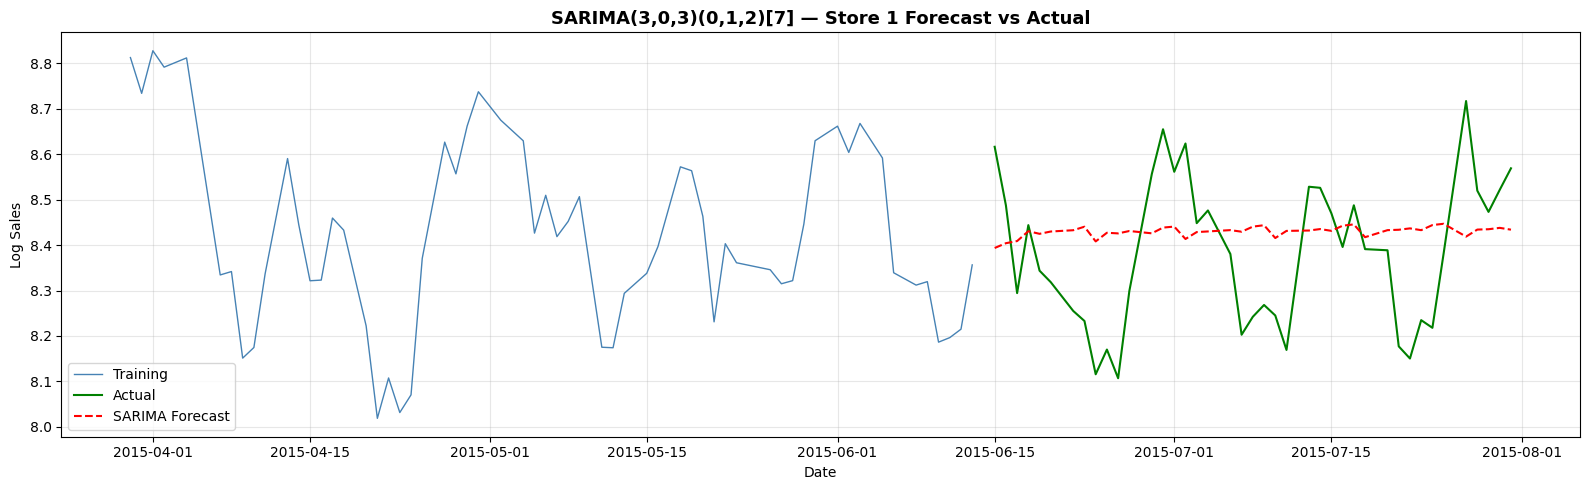

=== SARIMA(3,0,3)(0,1,2)[7] ===
RMSE : 738.29
MAE  : 633.24
MAPE : 15.13%
------------------------------


In [11]:
y_val = store1_val['LogSales'].dropna()

# Forecast
sarima_forecast = sarima_fit.forecast(steps=len(y_val))

# Plot
fig, ax = plt.subplots(figsize=(16, 5))

# Show last 60 days of training for context
ax.plot(y_train.index[-60:], y_train.values[-60:], 
        color='steelblue', label='Training', linewidth=1)
ax.plot(y_val.index, y_val.values, 
        color='green', label='Actual', linewidth=1.5)
ax.plot(y_val.index, sarima_forecast.values, 
        color='red', linestyle='--', label='SARIMA Forecast', linewidth=1.5)

ax.set_title('SARIMA(3,0,3)(0,1,2)[7] — Store 1 Forecast vs Actual', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Log Sales')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/08_sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate
sarima_results = evaluate_model(y_val.values, sarima_forecast.values, 
                                 'SARIMA(3,0,3)(0,1,2)[7]')
results.append(sarima_results)

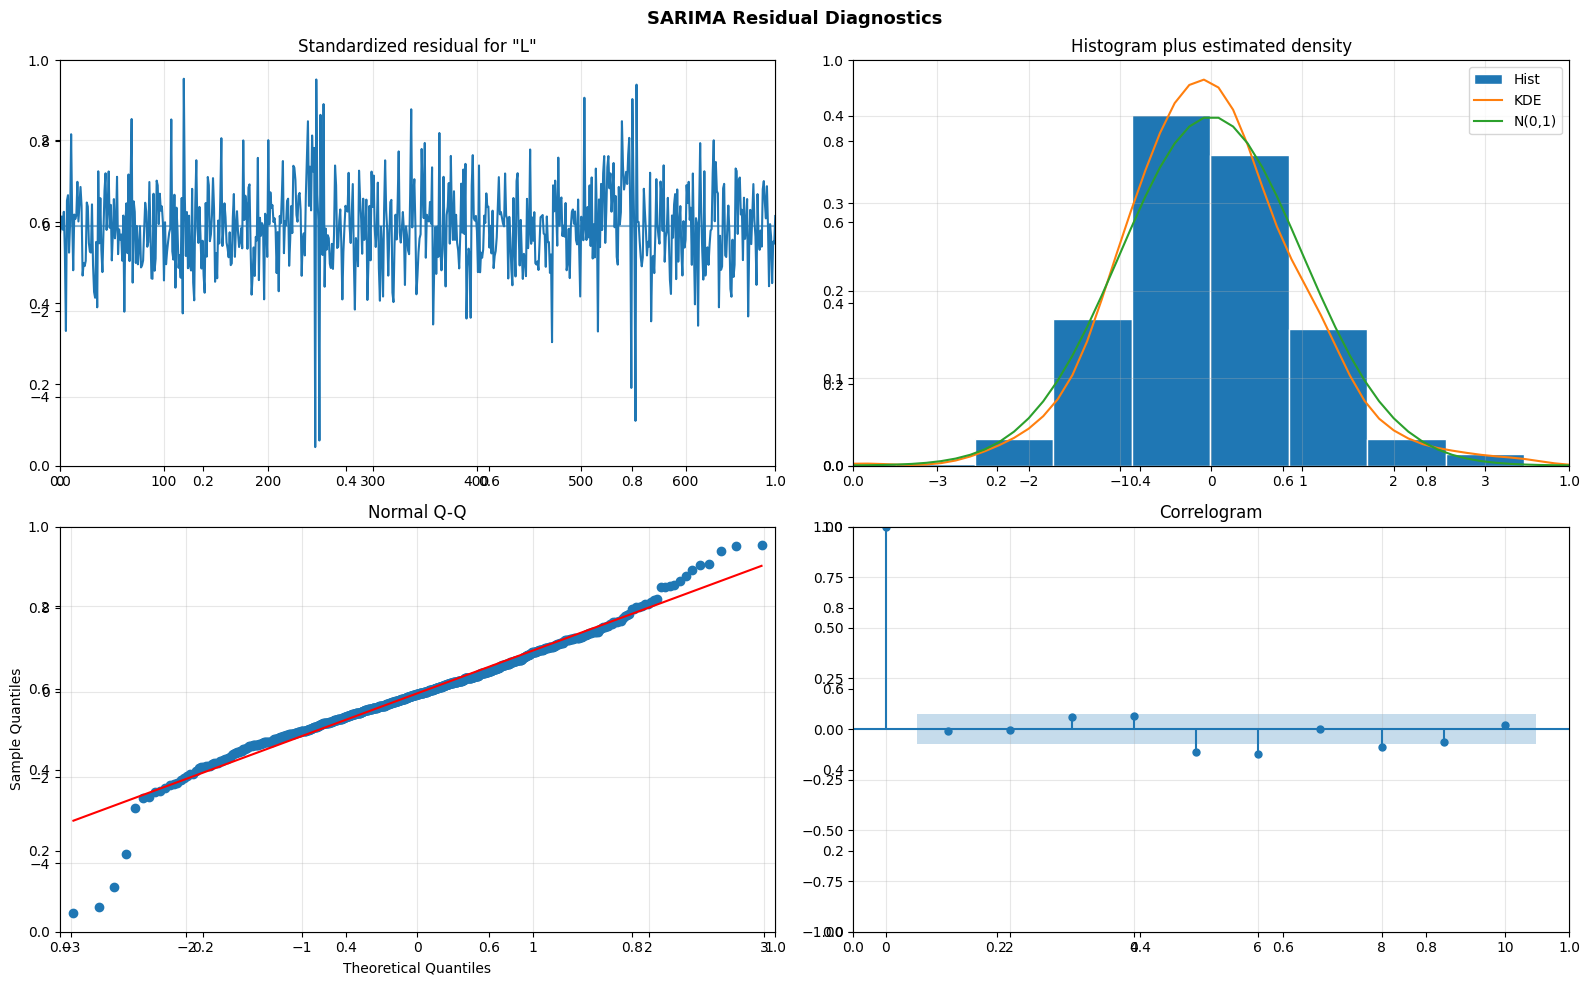

=== Ljung-Box Test (H0: No autocorrelation in residuals) ===
       lb_stat     lb_pvalue
7   232.944447  1.175106e-46
14  241.560806  1.593376e-43
21  243.364205  8.798993e-40

Conclusion: Residuals have autocorrelation ⚠️


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sarima_fit.plot_diagnostics(fig=fig)
plt.suptitle('SARIMA Residual Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/09_sarima_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box test for residual autocorrelation
lb_test = acorr_ljungbox(sarima_fit.resid, lags=[7, 14, 21], return_df=True)
print("=== Ljung-Box Test (H0: No autocorrelation in residuals) ===")
print(lb_test)
print("\nConclusion:", 
      "Residuals are white noise ✅" if all(lb_test['lb_pvalue'] > 0.05) 
      else "Residuals have autocorrelation ⚠️")

### SARIMA Model Results & Diagnostics

#### Model Summary Interpretation
- **ar.L1 (0.667, p≈0.000) and ar.L2 (0.643, p≈0.000)** — both highly 
  significant, confirming strong short-term autocorrelation
- **ar.L3 (-0.351, p≈0.000)** — significant negative AR term at lag 3
- **ma.L1 (0.036, p=0.710)** — NOT significant, suggests MA(1) term 
  is unnecessary — model could potentially be simplified
- **ma.S.L7 (-1.014, p≈0.000)** — highly significant seasonal MA term 
  confirming weekly seasonality is well captured
- **ma.S.L14 (0.022, p=0.666)** — NOT significant, second seasonal MA 
  term is unnecessary

#### Forecast Plot Observation
- SARIMA forecast is a **nearly flat line** — it converges quickly to 
  the mean and loses the weekly oscillation pattern
- This is a fundamental limitation of SARIMA for multi-step forecasting — 
  beyond a few steps ahead, forecasts revert to the conditional mean
- The model captures the **level** correctly (~8.4 log scale) but 
  misses the **weekly swings**

#### Residual Diagnostics
- **Standardized residuals** — appear random but not centered at 0, 
  showing a slight positive bias (~0.6)
- **Histogram** — heavier tails than normal distribution, confirmed by 
  Kurtosis=5.73 (normal=3)
- **Q-Q Plot** — mostly follows the diagonal but deviates at both tails, 
  confirming non-normality
- **Correlogram** — residuals appear mostly within confidence bands 
  which is good

#### Ljung-Box Test ⚠️
- p-value ≈ 0.000 at all lags — we **reject H₀** of no autocorrelation
- Residuals still contain significant autocorrelation — SARIMA has NOT 
  fully captured all temporal structure
- This is partly explained by the **promotion effect** — SARIMA has no 
  knowledge of promo days, so promo-driven sales spikes appear as 
  unexplained residuals
- **This motivates SARIMAX** — adding Promo as exogenous variable 
  should reduce residual autocorrelation

#### Jarque-Bera Test
- JB statistic=218.68, p≈0.000 — residuals are **not normally distributed**
- Driven by excess kurtosis (5.73) from holiday/promo outliers
- This is common in retail sales data and acceptable for forecasting purposes

#### Performance: MAPE = 15.13%
- Baseline SARIMA achieves 15.13% average error
- This will be our benchmark — SARIMAX and advanced models should improve on this

## 3. SARIMAX Model

We extend SARIMA by adding exogenous variables identified in EDA:
- **Promo** — increases sales by ~38.8% (Cohen's d=0.79)
- **SchoolHoliday** — affects customer footfall
- **StateHoliday** — significant sales impact on holiday days

The key advantage: SARIMAX can use **known future values** of these 
variables at forecast time — since promotion schedules are planned 
in advance, this is realistic for production forecasting.

In [14]:
exog_cols = ['Promo', 'SchoolHoliday', 'StateHoliday_Encoded']

# Align exog to y_train index exactly
exog_train = store1_train[exog_cols].reindex(y_train.index).fillna(0)
exog_val = store1_val[exog_cols].reindex(y_val.index).fillna(0)

print("y_train shape    :", y_train.shape)
print("exog_train shape :", exog_train.shape)
print("y_val shape      :", y_val.shape)
print("exog_val shape   :", exog_val.shape)
print("Indices aligned  :", y_train.index.equals(exog_train.index))

# Fit SARIMAX
sarimax_model = sm_SARIMAX(
    y_train,
    exog=exog_train,
    order=(3, 0, 3),
    seasonal_order=(0, 1, 2, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

y_train shape    : (712,)
exog_train shape : (712, 3)
y_val shape      : (41,)
exog_val shape   : (41, 3)
Indices aligned  : True
                                       SARIMAX Results                                        
Dep. Variable:                               LogSales   No. Observations:                  712
Model:             SARIMAX(3, 0, 3)x(0, 1, [1, 2], 7)   Log Likelihood                 344.282
Date:                                Fri, 10 Apr 2026   AIC                           -664.564
Time:                                        00:12:30   BIC                           -610.176
Sample:                                             0   HQIC                          -643.522
                                                - 712                                         
Covariance Type:                                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------

### SARIMAX Model Results

#### Model Improvement over SARIMA
| Metric | SARIMA | SARIMAX | Improvement |
|--------|--------|---------|-------------|
| AIC | -607.13 | -664.56 | -57.43 ✅ |
| BIC | -566.33 | -610.18 | -43.85 ✅ |
| Log Likelihood | 312.56 | 344.28 | +31.72 ✅ |

Lower AIC/BIC and higher log likelihood confirm SARIMAX is a 
significantly better model than SARIMA.

#### Exogenous Variable Coefficients
- **Promo (0.1376, p≈0.000)** ⭐ — highly significant! On a promo day, 
  log sales increase by 0.1376, equivalent to approximately 
  exp(0.1376)-1 = **14.8% increase in sales**
- **SchoolHoliday (-0.0217, p=0.375)** — NOT significant, school 
  holidays don't independently affect Store 1's sales after controlling 
  for other factors
- **StateHoliday_Encoded (coef≈0, p=1.000)** — completely insignificant.
  This is likely because state holidays are extremely rare (910 out of 
  844,338 rows) and their effect is already captured by the seasonal component

#### ARIMA Component
- **ar.L1, ar.L2, ar.L3** — all significant, consistent with SARIMA
- **ma.S.L7 (-0.914, p≈0.000)** — seasonal MA term remains highly 
  significant confirming weekly seasonality
- Several MA terms insignificant — model could potentially be simplified

#### ⚠️ Warning: Singular Covariance Matrix
- Condition number = 7.97e+18 — indicates near-multicollinearity 
  between some parameters
- Standard errors may be unreliable for some coefficients
- This is partly due to StateHoliday being nearly zero variance in 
  the data — will be addressed by removing it in a refined model

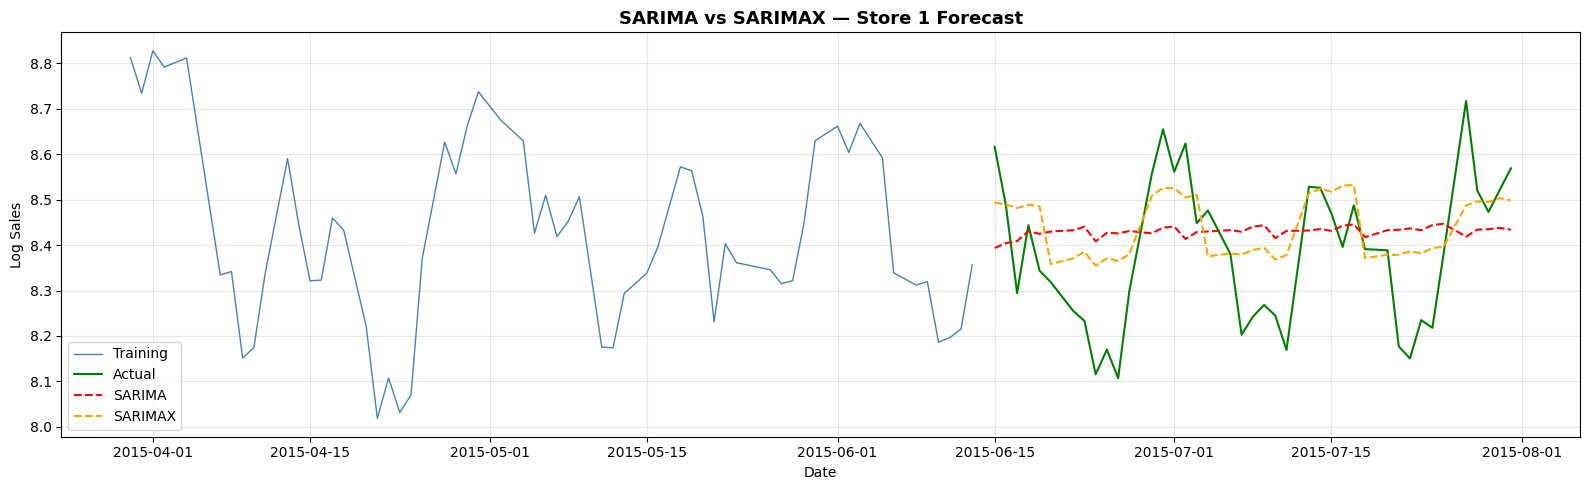

=== SARIMAX(3,0,3)(0,1,2)[7] ===
RMSE : 553.95
MAE  : 452.53
MAPE : 11.02%
------------------------------


In [15]:
sarimax_forecast = sarimax_fit.forecast(steps=len(y_val), exog=exog_val)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_train.index[-60:], y_train.values[-60:],
        color='steelblue', label='Training', linewidth=1)
ax.plot(y_val.index, y_val.values,
        color='green', label='Actual', linewidth=1.5)
ax.plot(y_val.index, sarima_forecast.values,
        color='red', linestyle='--', label='SARIMA', linewidth=1.5)
ax.plot(y_val.index, sarimax_forecast.values,
        color='orange', linestyle='--', label='SARIMAX', linewidth=1.5)

ax.set_title('SARIMA vs SARIMAX — Store 1 Forecast', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Log Sales')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/10_sarimax_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate
sarimax_results = evaluate_model(y_val.values, sarimax_forecast.values,
                                  'SARIMAX(3,0,3)(0,1,2)[7]')
results.append(sarimax_results)

In [16]:
lb_test_sarimax = acorr_ljungbox(sarimax_fit.resid, lags=[7, 14, 21], 
                                  return_df=True)
print("=== Ljung-Box Test — SARIMAX Residuals ===")
print(lb_test_sarimax)
print("\nConclusion:",
      "Residuals are white noise ✅" if all(lb_test_sarimax['lb_pvalue'] > 0.05)
      else "Residuals have autocorrelation ⚠️")

=== Ljung-Box Test — SARIMAX Residuals ===
       lb_stat     lb_pvalue
7   261.991310  7.747821e-53
14  272.339731  6.741424e-50
21  273.263369  8.434548e-46

Conclusion: Residuals have autocorrelation ⚠️


### SARIMAX Performance vs SARIMA

| Metric | SARIMA | SARIMAX | Improvement |
|--------|--------|---------|-------------|
| RMSE | 738.29 | 553.95 | -24.9% ✅ |
| MAE | 633.24 | 452.53 | -28.5% ✅ |
| MAPE | 15.13% | 11.02% | -4.11pp ✅ |

Adding just one significant exogenous variable (Promo) reduced 
forecast error by ~27% on average — confirming our EDA finding 
that promotions are the strongest predictor in the dataset.

### Forecast Plot Observation
- SARIMAX (orange) shows more variation than SARIMA (red) — 
  it correctly spikes upward on promo days and pulls back on 
  non-promo days
- Both models still miss the full amplitude of weekly swings — 
  this is the fundamental limitation of multi-step SARIMA forecasting
- Neither model captures the sharp dip around July 1 — likely 
  a store-specific event not captured by any feature

### Ljung-Box Test ⚠️
- Residuals still show significant autocorrelation despite improvement
- p-value ≈ 0.000 at all lags — unexplained structure remains
- Possible reasons:
  1. Annual seasonality (s=365) not captured by weekly SARIMA
  2. Store-specific events (refurbishments, local competition)
  3. Non-linear interactions between promo and day-of-week 
     that SARIMAX can't model linearly
- This motivates moving to **Prophet and LightGBM** which can 
  capture multiple seasonalities and non-linear effects

## 4. Holt-Winters Exponential Smoothing

Holt-Winters is a classical forecasting method that uses weighted 
averages of past observations, giving more weight to recent data.

Three components:
- **Alpha (α)** — smoothing factor for level
- **Beta (β)** — smoothing factor for trend  
- **Gamma (γ)** — smoothing factor for seasonality

We use the multiplicative seasonal variant with period=7.
Unlike SARIMA, Holt-Winters has no concept of exogenous variables 
but is computationally simpler and often surprisingly competitive.

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal='add',
    seasonal_periods=7,
    damped_trend=True
)

hw_fit = hw_model.fit(optimized=True)

print("=== Holt-Winters Parameters ===")
print(f"Alpha (level)     : {hw_fit.params['smoothing_level']:.4f}")
print(f"Beta  (trend)     : {hw_fit.params['smoothing_trend']:.4f}")
print(f"Gamma (seasonal)  : {hw_fit.params['smoothing_seasonal']:.4f}")
print(f"Phi   (damping)   : {hw_fit.params['damping_trend']:.4f}")

=== Holt-Winters Parameters ===
Alpha (level)     : 0.7902
Beta  (trend)     : 0.0000
Gamma (seasonal)  : 0.0000
Phi   (damping)   : 0.8000


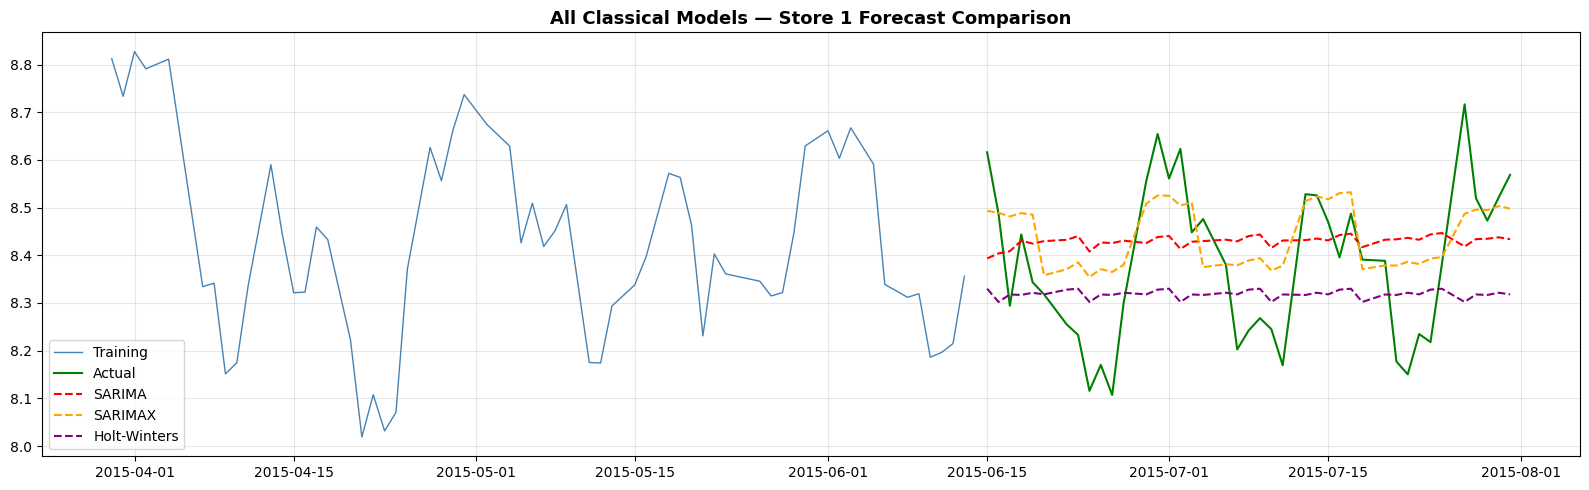

=== Holt-Winters ===
RMSE : 785.37
MAE  : 646.83
MAPE : 13.93%
------------------------------


In [18]:
hw_forecast = hw_fit.forecast(steps=len(y_val))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_train.index[-60:], y_train.values[-60:],
        color='steelblue', label='Training', linewidth=1)
ax.plot(y_val.index, y_val.values,
        color='green', label='Actual', linewidth=1.5)
ax.plot(y_val.index, sarima_forecast.values,
        color='red', linestyle='--', label='SARIMA', linewidth=1.5)
ax.plot(y_val.index, sarimax_forecast.values,
        color='orange', linestyle='--', label='SARIMAX', linewidth=1.5)
ax.plot(y_val.index, hw_forecast.values,
        color='purple', linestyle='--', label='Holt-Winters', linewidth=1.5)

ax.set_title('All Classical Models — Store 1 Forecast Comparison',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/11_all_classical_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

hw_results = evaluate_model(y_val.values, hw_forecast.values, 'Holt-Winters')
results.append(hw_results)

=== Classical Models Comparison ===
                   Model       RMSE        MAE      MAPE
SARIMAX(3,0,3)(0,1,2)[7] 553.950572 452.532179 11.024373
            Holt-Winters 785.365924 646.825695 13.932587
 SARIMA(3,0,3)(0,1,2)[7] 738.287514 633.241906 15.126245


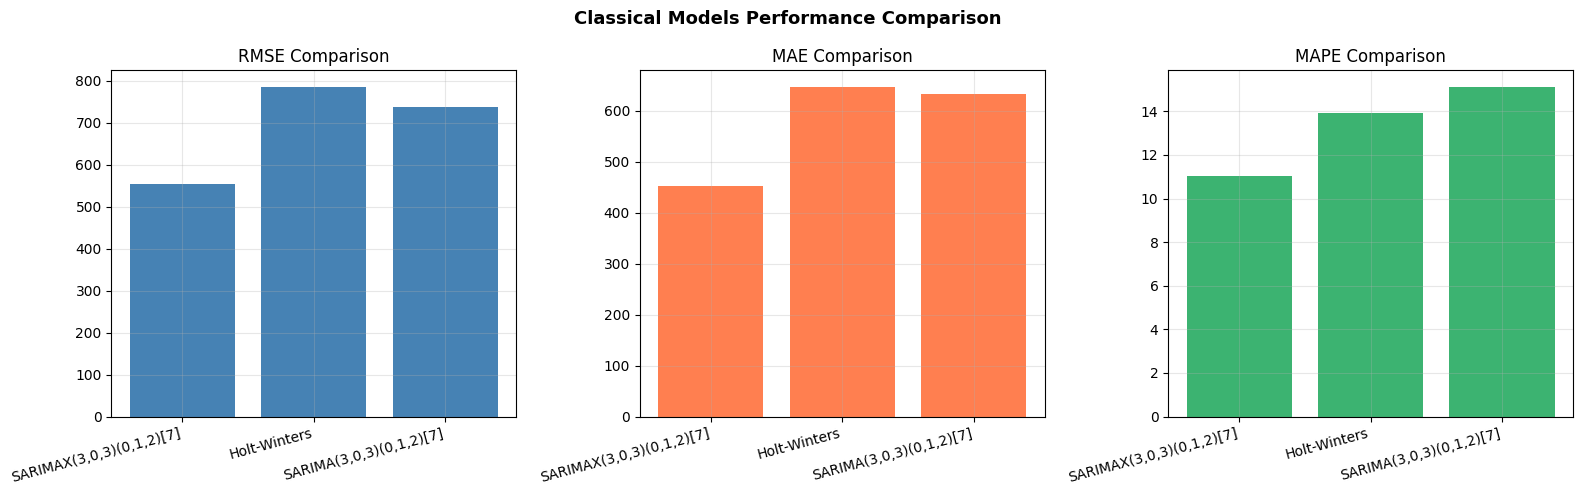

In [19]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MAPE').reset_index(drop=True)

print("=== Classical Models Comparison ===")
print(results_df.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['RMSE', 'MAE', 'MAPE']
colors = ['steelblue', 'coral', 'mediumseagreen']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[i].bar(results_df['Model'], results_df[metric], color=color)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_xticklabels(results_df['Model'], rotation=15, ha='right')

plt.suptitle('Classical Models Performance Comparison', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/12_classical_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Classical Models — Final Summary

### Performance Comparison
| Model | RMSE | MAE | MAPE | Rank |
|-------|------|-----|------|------|
| SARIMAX(3,0,3)(0,1,2)[7] | 553.95 | 452.53 | 11.02% | 1st 🥇 |
| Holt-Winters | 785.37 | 646.83 | 13.93% | 2nd 🥈 |
| SARIMA(3,0,3)(0,1,2)[7] | 738.29 | 633.24 | 15.13% | 3rd 🥉 |

### Key Findings

**1. SARIMAX wins clearly**
Adding Promo as exogenous variable reduced MAPE from 15.13% to 11.02% 
— a 27% improvement. This confirms promotions are the single most 
important predictor in the dataset.

**2. Holt-Winters surprisingly competitive**
Despite being the simplest model with no exogenous variables, 
Holt-Winters (13.93%) outperformed SARIMA (15.13%). 

Holt-Winters parameters tell an interesting story:
- Alpha=0.79 — very high, model relies heavily on recent observations
- Beta=0.00 — no trend component needed, confirming flat trend from EDA
- Gamma=0.00 — seasonal component not updating, fixed weekly pattern
- Phi=0.80 — moderate trend damping

**3. All models share a common limitation**
All three forecasts converge toward the mean and fail to capture 
the full amplitude of weekly swings. This is because:
- SARIMA/SARIMAX: multi-step forecasts revert to conditional mean
- Holt-Winters: underpredicts volatility

**4. Residual autocorrelation persists**
Ljung-Box test rejected white noise for both SARIMA and SARIMAX — 
unexplained structure remains, likely from:
- Annual seasonality (s=365) not modelled
- Non-linear promo × day-of-week int